- Pretrain / SFT: NTP (next token prediction), teacher forcing 训练机制。
    - 等价于最大似然估计（MLE）：
        - $P(X \mid \theta) = \prod_{t=1}^{T} P(x_t \mid x_{<t}, \theta)$
        - $\mathcal{L}_{\text{MLE}} = \arg\max_{\theta} \sum_{t=1}^{T} \log P(x_t \mid x_{<t}, \theta)$ 
        - $\arg\max_{\theta} (\text{Log-Likelihood}) \equiv \arg\min_{\theta} (\text{Cross-Entropy Loss})$
            - $\max \log P = - \min (-\log P)$
        - 似然与概率
            -  $P(x \mid \theta)$ 描述了在已知参数下，不同数据 $x$ 出现的分布情况。
            -   $L(\theta \mid x) = f(x \mid \theta)$ 描述了在固定数据下，不同参数 $\theta$ 能够“重现”该数据的能力或合理性。
    - teacher forcing：
        - Teacher Forcing（训练时）： 模型在预测第 $t$ 个 Token 时，条件概率为 $P(x_t \mid x_{<t}^*, \theta)$，其中 $x_{<t}^*$ 是来自训练语料的完美真实历史。（没有自回归的采样与生成，都是 gt）
            - 对一个句子做 shift，整体算 loss；批处理
        - Free-running（推理时）： 模型只能依赖自己生成的历史，条件概率变为 $P(x_t \mid \hat{x}_{<t}, \theta)$，其中 $\hat{x}_{<t}$ 包含了模型之前可能生成的错误或次优 Token。

### cross entropy loss recap

$$
L = -\log(p_t)
$$
> 多分类问题，用交叉熵损失；在 gt 位置定义loss，但 bp 时，更新整个 layer weight（unembedding matrix，`lm_head`），而非对应该位置的 vector。对于 llm 的 ntp，单次位置的更新会稠密地覆盖整个词表权重。

- notations
    - $h \in \mathbb{R}^{1 \times d}$：代表 Transformer 最后一层输出的隐状态向量（Hidden state）。row vector 
    - $W \in \mathbb{R}^{V \times d}$：代表未绑定偏置的线性分类层权重矩阵（Unembedding matrix），其中 $V$ 是词表大小，$d$ 是隐藏层维度。
    - $t$：代表真实的标签（Ground Truth），即下一个正确词在词表中的索引。
    - $y \in \mathbb{R}^{1 \times V}$：代表将标签 $t$ 进行 One-Hot 编码后的向量，满足当 $j = t$ 时 $y_j = 1$，其余 $y_{j \neq t} = 0$。row vector
- Logits -> Cross-Entropy Loss
    - 从隐空间映射到词表空间的过程：$z = h W^T$，其中 $z \in \mathbb{R}^{1 \times V}$ 称为 Logits。对于词表中的第 $j$ 个词，其对应的 logit 值为向量内积：$z_j = h \cdot w_j$，这里 $w_j$ 是矩阵 $W$ 的第 $j$ 行。
    - Logits 需要通过 Softmax 函数映射为离散的概率分布 $p \in \mathbb{R}^{1 \times V}$。对于词表中的任意词 $j$，其预测概率 $p_j$ 为：$p_j = \frac{\exp(z_j)}{\sum_{k=1}^V \exp(z_k)}$
    - Cross-Entropy Loss：$L = -\log(p_t)$
        - 模型的目标是最大化正确词 $t$ 的概率，即最小化负对数似然（Negative Log-Likelihood）。
        - 结合 One-Hot 向量 $y$，该标量损失可以被推广为标准交叉熵公式的全局求和形式

#### gradient

- 步骤一：求解 Loss 对 Logits 的梯度 ($\frac{\partial L}{\partial z_j}$)
    - 情况 A：当 $j = t$ 时（对应正确目标词）
        - $\frac{\partial p_t}{\partial z_t} = p_t (1 - p_t)$ （softmax gradient，quotient rule，分子分母都有）
        - $\frac{\partial L}{\partial z_t} = -\frac{1}{p_t} \cdot \frac{\partial p_t}{\partial z_t} = -(1 - p_t) = p_t - 1$
    - 情况 B：当 $j \neq t$ 时（对应非目标词）
        - $\frac{\partial p_t}{\partial z_j} = -p_t p_j$（softmax gradient，分母的 component）
        - $\frac{\partial L}{\partial z_j} = -\frac{1}{p_t} \cdot (-p_t p_j) = p_j$
    - 统一的向量形式：$\frac{\partial L}{\partial z} = p - y\in \mathbb{R}^{1 \times V}$（`probs - y_one_hot`）
- 步骤二：求解 Loss 对 权重矩阵 W 的梯度 ($\nabla_W L$)
    - 已知 $z = h W^T$，展开到标量级别，对于 Logits 中的第 $j$ 个元素有 $z_j = \sum_{k=1}^d h_k W_{jk}$。因此，$z_j$ 对权重矩阵中第 $j$ 行、第 $k$ 列的元素 $W_{jk}$ 的偏导数为：$\frac{\partial z_j}{\partial W_{jk}} = h_k$
    - 根据链式法则求解最终的梯度参数：$$\frac{\partial L}{\partial W_{jk}} = \frac{\partial L}{\partial z_j} \cdot \frac{\partial z_j}{\partial W_{jk}} = (p_j - y_j) h_k$$
- 矩阵化表示：
    - 将上述标量偏导数重组为矩阵形式，这正是计算图中的外积（Outer Product）。设误差向量 $\delta = (p - y)^T$（维度为 $V \times 1$），隐状态向量为 $h$（维度为 $1 \times d$），则完整的梯度矩阵为：$$\nabla_W L = (p - y)^T \otimes h$$
    - 其维度为 $(V \times 1) \times (1 \times d) = V \times d$。这完美对应了初始权重矩阵 $W$ 的形状，也精准映射了 `grad_logits_manual.T @ h`

$$
\begin{bmatrix}
g_1 \\
g_2 \\
\vdots \\
g_V
\end{bmatrix}
\begin{bmatrix}
h_1 & h_2 & \cdots & h_D
\end{bmatrix}=
\begin{bmatrix}
g_1h_1 & g_1h_2 & \cdots & g_1h_D \\
g_2h_1 & g_2h_2 & \cdots & g_2h_D \\
\vdots & \vdots & \ddots & \vdots \\
g_Vh_1 & g_Vh_2 & \cdots & g_Vh_D
\end{bmatrix}
$$

In [29]:
import torch
import torch.nn.functional as F
torch.manual_seed(42)

V = 5 # 词表大小 (Vocab size)
d = 3 # 隐藏层维度 (Hidden dimension)

# Transformer 最后一层输出的单个 Token 的隐藏状态 h
h = torch.randn(1, d) * 2
print('h', h)
# lm_head 的无偏置权重矩阵 W (即 unembedding matrix)
W = torch.randn(V, d, requires_grad=True) 

# 前向传播计算未归一化的 logits
logits = h @ W.T # 维度: (1, V)

# 设定真实标签 (Ground Truth)
target = torch.tensor([2]) # 假设在词表 V 中，正确的词索引为 2

# ==========================================
# 方式一：调用 PyTorch 官方 API 进行自动求导
# ==========================================
loss_api = F.cross_entropy(logits, target)
loss_api.backward()
grad_W_api = W.grad.clone() # 提取自动求导引擎计算出的 W 梯度矩阵

W.grad.zero_() # 清空梯度，为下方手动计算让路

# ==========================================
# 方式二：手动数学推导与计算 (完全对应数学公式)
# ==========================================
# [前向阶段]: a. 计算 Softmax 概率分布
probs = torch.softmax(logits, dim=-1) # 这就是公式中的 p_j
print('probs', probs)

# [前向阶段]: b. 提取目标词的概率 p_i 并计算交叉熵 Loss
p_i = probs[0, target[0]]
loss_manual = -torch.log(p_i) # L = -log(p_i), scalar

# [反向阶段]: c. 手动计算梯度 (验证核心推导: ∂L/∂z = p - y)
# 构造 One-Hot 标签 y
y_one_hot = torch.zeros_like(logits)
y_one_hot[0, target[0]] = 1.0

# 核心步骤：计算 Loss 对 logits 的梯度
grad_logits_manual = probs - y_one_hot # 维度: (1, V)

# 核心步骤：根据链式法则计算 W 的梯度: ∂L/∂W = (p - y)^T @ h
# 维度对齐验证: (V, 1) @ (1, d) -> (V, d)，完美对应 W 的 shape
grad_W_manual = grad_logits_manual.T @ h 

# 打印与对比结果
print(f"API 计算的 Loss:    {loss_api.item():.6f}")
print(f"手动计算的 Loss:    {loss_manual.item():.6f}\n")

print("--- API 自动计算的 W 矩阵梯度 ---")
print(grad_W_api)
print("\n--- 手动计算的 W 矩阵梯度 (p_j - y_j) * h^T ---")
print(grad_W_manual)

# 验证两者矩阵差异是否趋近于 0 (受限于浮点数精度)
diff = torch.abs(grad_W_api - grad_W_manual).max().item()
print(f"\n最大浮点误差 (Max Error): {diff:.8e}")

h tensor([[0.6734, 0.2576, 0.4689]])
probs tensor([[0.0654, 0.3801, 0.1638, 0.0701, 0.3206]], grad_fn=<SoftmaxBackward0>)
p_i.shape tensor(0.1638, grad_fn=<SelectBackward0>) torch.Size([])
API 计算的 Loss:    1.809024
手动计算的 Loss:    1.809024

--- API 自动计算的 W 矩阵梯度 ---
tensor([[ 0.0440,  0.0168,  0.0306],
        [ 0.2560,  0.0979,  0.1782],
        [-0.5631, -0.2154, -0.3921],
        [ 0.0472,  0.0181,  0.0329],
        [ 0.2159,  0.0826,  0.1503]])

--- 手动计算的 W 矩阵梯度 (p_j - y_j) * h^T ---
tensor([[ 0.0440,  0.0168,  0.0306],
        [ 0.2560,  0.0979,  0.1782],
        [-0.5631, -0.2154, -0.3921],
        [ 0.0472,  0.0181,  0.0329],
        [ 0.2159,  0.0826,  0.1503]], grad_fn=<MmBackward0>)

最大浮点误差 (Max Error): 1.49011612e-08


In [32]:
import numpy as np
print((0.0654 - 0) * np.array([[0.6734, 0.2576, 0.4689]]))
print((0.1638 - 1) * np.array([[0.6734, 0.2576, 0.4689]]))

[[0.04404036 0.01684704 0.03066606]]
[[-0.56309708 -0.21540512 -0.39209418]]


-------

梯度公式为 $\frac{\partial L}{\partial W_j} = (p_j - y_j) h^T$。在 SGD 优化器执行梯度下降操作 $W_{new} = W_{old} - \eta \nabla W$ 时：
- 对于 GT（索引 2）：系数是 $(p_2 - 1)$，严格为负数。负负得正，这意味着模型在将 $W_2$ 向量加上一部分 $h$ 向量，使其在几何空间中向当前上下文的特征表达 $h$ 靠拢。
- 对于非 GT（其他索引）：系数是 $p_j$，严格为正数。这意味着模型在将其他 $W_j$ 向量减去一部分 $h$ 向量，强迫它们在空间中远离 $h$。

In [14]:
grad_W_api.sum(axis=0)

tensor([-1.1921e-07, -2.9802e-08, -2.9802e-08])

Softmax 交叉熵损失函数下梯度的零和守恒定律（Zero-Sum Conservation）。因为所有词的概率之和等于 1（$\sum_{j=0}^{V-1} p_j = 1$），那么所有标量系数之和必然为零：
$$ \sum_{j=0}^{V-1} (p_j - y_j) = \sum_{j=0}^{V-1} p_j - \sum_{j=0}^{V-1} y_j = 1 - 1 = 0 $$

In [21]:
grad_W_api[2] /grad_W_api[0], grad_W_api[2] / grad_W_api[1]

(tensor([-12.7945, -12.7945, -12.7945]), tensor([-2.1999, -2.1999, -2.1999]))

$$
\text{Ratio}(a, b) = \frac{p_a - y_a}{p_b - y_b}
$$

In [27]:
(probs[0][2] - 1) / (probs[0][0] - 0), (probs[0][2] - 1) / (probs[0][1] - 0)

(tensor(-12.7945, grad_fn=<DivBackward0>),
 tensor(-2.1999, grad_fn=<DivBackward0>))

In [22]:
torch.linalg.matrix_rank(grad_W_api)

tensor(1)

当这种秩为 1 （$(p-y)\in \mathbb{R}^{|V|}$ 两者外积得到 $|V|\times d$）的更新在海量数据上不断累积时，会导致一个著名的现象——各向异性（Anisotropy）与表征坍塌（Representation Collapse）。

### gradient descent

> geometric intuition of gradient descent

对单个训练位置，有

$$z_j = h^\top w_j, \quad p_j = \frac{\exp(z_j)}{\sum_k \exp(z_k)},$$

其中 $h$ 是当前位置的 final hidden state，$w_j$ 是 `lm_head` 中第 $j$ 个 token 的行向量。交叉熵损失

$$L = -\log p_y$$

对 $w_i$ 的梯度是

$$\nabla_{w_i} L = (p_i - \mathbf{1}_{i=y}) h.$$

梯度下降更新为

$$w_i \leftarrow w_i - \eta (p_i - \mathbf{1}_{i=y}) h.$$

分两种情况看：

当 $i = y$，也就是 token $i$ 是当前位置的正确下一个 token：

$$\Delta w_i = \eta (1 - p_i) h.$$

这会把 $w_i$ 往 $h$ 的方向拉。直观上，模型在学习：“遇到类似这个 hidden state 的上下文时，应该更容易输出 token $i$。”

当 $i \neq y$，也就是 token $i$ 不是正确答案：

$$\Delta w_i = -\eta p_i h.$$

这会把 $w_i$ 往远离 $h$ 的方向推。直观上，模型在学习：“这个上下文下不该输出 token $i$。”

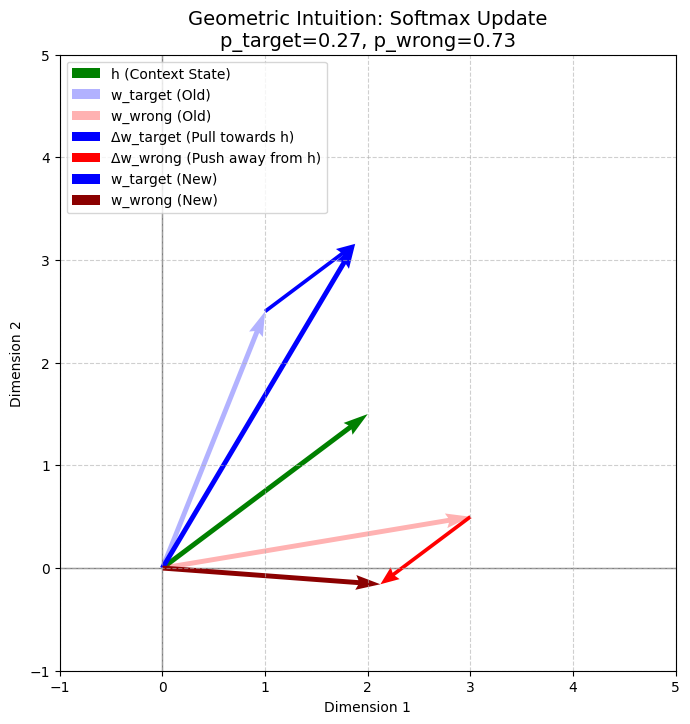

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 设置二维向量空间以便于可视化
# h: 当前上下文的 hidden state
h = np.array([2.0, 1.5]) 

# w_target: 正确 token 的初始权重向量 (稍微偏离 h)
w_target = np.array([1.0, 2.5]) 

# w_wrong: 错误 token 的初始权重向量 (也在某个方向上)
w_wrong = np.array([3.0, 0.5])  

# 计算 Logits 和 Softmax 概率
W = np.array([w_target, w_wrong])
logits = W @ h
exp_logits = np.exp(logits - np.max(logits)) # 防止溢出
probs = exp_logits / np.sum(exp_logits)

# 学习率
eta = 0.6

# 计算更新量 (梯度下降的步长)
# 对于正确答案 (拉近): Δw_target = η * (1 - p_target) * h
dw_target = eta * (1 - probs[0]) * h
w_target_new = w_target + dw_target

# 对于错误答案 (推远): Δw_wrong = - η * p_wrong * h
dw_wrong = - eta * probs[1] * h
w_wrong_new = w_wrong + dw_wrong

# 开始绘图
fig, ax = plt.subplots(figsize=(10, 8))
ax.axvline(0, color='grey', lw=1, zorder=0)
ax.axhline(0, color='grey', lw=1, zorder=0)

origin = np.array([0, 0])

# 绘制原始向量
ax.quiver(*origin, *h, color='green', scale=1, scale_units='xy', angles='xy', label='h (Context State)', width=0.008)
ax.quiver(*origin, *w_target, color='blue', scale=1, scale_units='xy', angles='xy', alpha=0.3, label='w_target (Old)', width=0.008)
ax.quiver(*origin, *w_wrong, color='red', scale=1, scale_units='xy', angles='xy', alpha=0.3, label='w_wrong (Old)', width=0.008)

# 绘制更新向量 (增量)
ax.quiver(*w_target, *dw_target, color='blue', scale=1, scale_units='xy', angles='xy', width=0.006, headwidth=4, label='Δw_target (Pull towards h)')
ax.quiver(*w_wrong, *dw_wrong, color='red', scale=1, scale_units='xy', angles='xy', width=0.006, headwidth=4, label='Δw_wrong (Push away from h)')

# 绘制更新后的向量
ax.quiver(*origin, *w_target_new, color='blue', scale=1, scale_units='xy', angles='xy', label='w_target (New)', width=0.008)
ax.quiver(*origin, *w_wrong_new, color='darkred', scale=1, scale_units='xy', angles='xy', label='w_wrong (New)', width=0.008)

# 辅助线和设置
ax.set_xlim(-1, 5)
ax.set_ylim(-1, 5)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='upper left', fontsize=10)
ax.set_title(f"Geometric Intuition: Softmax Update\np_target={probs[0]:.2f}, p_wrong={probs[1]:.2f}", fontsize=14)
ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
ax.set_aspect('equal')

# plt.savefig('gradient_update_viz.png')
plt.show()

经过这种平移相加，深蓝色向量 $w_{\text{target}}$ (New) 显著地向 $h$ 靠拢（夹角缩小，未来内积增大）；而深红色向量 $w_{\text{wrong}}$ (New) 被强行扭转了方向，甚至跨越了 X 轴（夹角变大，未来内积急剧缩小）。这一“拉”一“推”，完成了模型对该上下文认知的修正。